In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from enum import IntFlag, auto
from scipy.stats import mannwhitneyu


sns.set_style("whitegrid")

In [19]:
class Genre(IntFlag):
    SCI_FI = auto()
    BIOGRAPHY = auto()
    CRIME = auto()
    WAR = auto()
    FILM_NOIR = auto()
    WESTERN = auto()
    TALK_SHOW = auto()
    COMEDY = auto()
    ADULT = auto()
    FAMILY = auto()
    HISTORY = auto()
    FANTASY = auto()
    ACTION = auto()
    ANIMATION = auto()
    DOCUMENTARY = auto()
    GAME_SHOW = auto()
    THRILLER = auto()
    MYSTERY = auto()
    REALITY_TV = auto()
    NEWS = auto()
    HORROR = auto()
    ADVENTURE = auto()
    SPORT = auto()
    MUSIC = auto()
    ROMANCE = auto()
    MUSICAL = auto()
    DRAMA = auto()


GENRE_BY_NAME = {
    "Sci-Fi": Genre.SCI_FI,
    "Biography": Genre.BIOGRAPHY,
    "Crime": Genre.CRIME,
    "War": Genre.WAR,
    "Film-Noir": Genre.FILM_NOIR,
    "Western": Genre.WESTERN,
    "Talk-Show": Genre.TALK_SHOW,
    "Comedy": Genre.COMEDY,
    "Adult": Genre.ADULT,
    "Family": Genre.FAMILY,
    "History": Genre.HISTORY,
    "Fantasy": Genre.FANTASY,
    "Action": Genre.ACTION,
    "Animation": Genre.ANIMATION,
    "Documentary": Genre.DOCUMENTARY,
    "Game-Show": Genre.GAME_SHOW,
    "Thriller": Genre.THRILLER,
    "Mystery": Genre.MYSTERY,
    "Reality-TV": Genre.REALITY_TV,
    "News": Genre.NEWS,
    "Horror": Genre.HORROR,
    "Adventure": Genre.ADVENTURE,
    "Sport": Genre.SPORT,
    "Music": Genre.MUSIC,
    "Romance": Genre.ROMANCE,
    "Musical": Genre.MUSICAL,
    "Drama": Genre.DRAMA,
}


In [20]:
df = pd.read_parquet('movies.parquet')

In [22]:
def bitmask_to_list(mask: int) -> list[str]:
    l = []
    for g in Genre:
        if mask & g:
            l.append(g.name)
    return l

In [24]:
df['genres'] = df['genres'].apply(bitmask_to_list)

In [25]:
df.head()

,tconst,primaryTitle,originalTitle,startYear,genres
8,tt0000009,Miss Jerry,Miss Jerry,1894.0,[ROMANCE]
144,tt0000147,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,1897.0,"[DOCUMENTARY, NEWS, SPORT]"
498,tt0000502,Bohemios,Bohemios,1905.0,[]
570,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,1906.0,"[BIOGRAPHY, ACTION, ADVENTURE]"
587,tt0000591,The Prodigal Son,L'enfant prodigue,1907.0,[DRAMA]


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 742013 entries, 8 to 12402706
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   tconst         742013 non-null  object 
 1   primaryTitle   742010 non-null  object 
 2   originalTitle  742010 non-null  object 
 3   startYear      630906 non-null  float64
 4   genres         742013 non-null  object 
dtypes: float64(1), object(4)
memory usage: 34.0+ MB


In [29]:
df.describe()

,startYear
count,630906.000000
mean,1994.729926
std,30.069907
min,1894.000000
25%,1977.000000
50%,2008.000000
75%,2018.000000
max,2031.000000


In [33]:
df2 = pd.read_parquet('ratings.parquet')

df_final = df.merge(df2)

In [34]:
df_final.head()

,tconst,primaryTitle,originalTitle,startYear,genres,averageRating,numVotes
0,tt0000009,Miss Jerry,Miss Jerry,1894.0,[ROMANCE],5.3,236
1,tt0000147,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,1897.0,"[DOCUMENTARY, NEWS, SPORT]",5.3,597
2,tt0000502,Bohemios,Bohemios,1905.0,[],3.5,26
3,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,1906.0,"[BIOGRAPHY, ACTION, ADVENTURE]",6.0,1065
4,tt0000591,The Prodigal Son,L'enfant prodigue,1907.0,[DRAMA],5.0,39


In [36]:
# Valores nulos por coluna
df_final.isnull().sum()

,0
tconst,0
primaryTitle,2
originalTitle,2
startYear,36
genres,0
averageRating,0
numVotes,0


In [37]:
# Remove listas vazias
df_genres = df_final[df_final["genres"].map(len) > 0].copy()

# Cria uma linha para cada gênero
df_genres = df_genres.explode("genres")

df_genres.head()

,tconst,primaryTitle,originalTitle,startYear,genres,averageRating,numVotes
0,tt0000009,Miss Jerry,Miss Jerry,1894.0,ROMANCE,5.3,236
1,tt0000147,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,1897.0,DOCUMENTARY,5.3,597
1,tt0000147,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,1897.0,NEWS,5.3,597
1,tt0000147,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,1897.0,SPORT,5.3,597
3,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,1906.0,BIOGRAPHY,6.0,1065


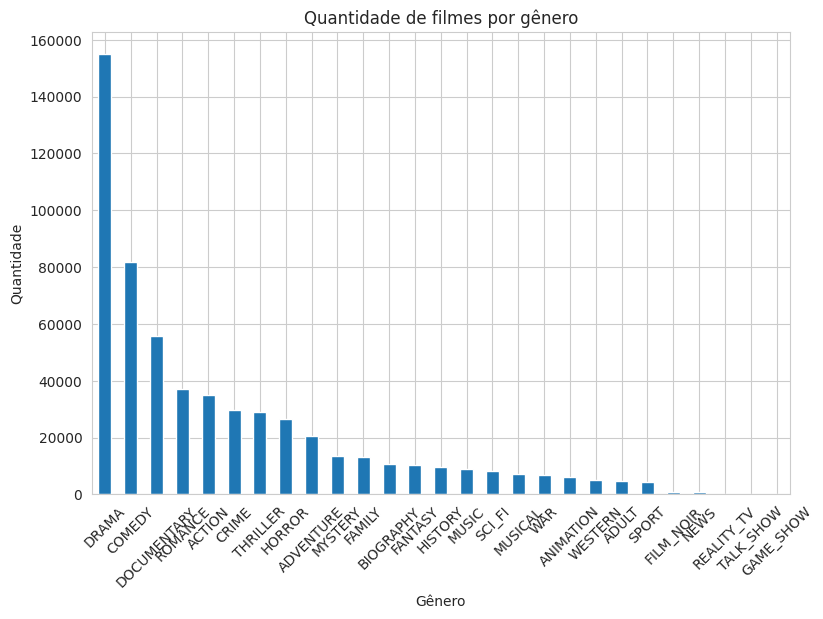

In [67]:
# Gêneros com mais filmes

genre_count = (
    df_genres["genres"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,6))

genre_count.plot(kind="bar")

plt.title("Quantidade de filmes por gênero")
plt.xlabel("Gênero")
plt.ylabel("Quantidade")

plt.xticks(rotation=45)

plt.show()

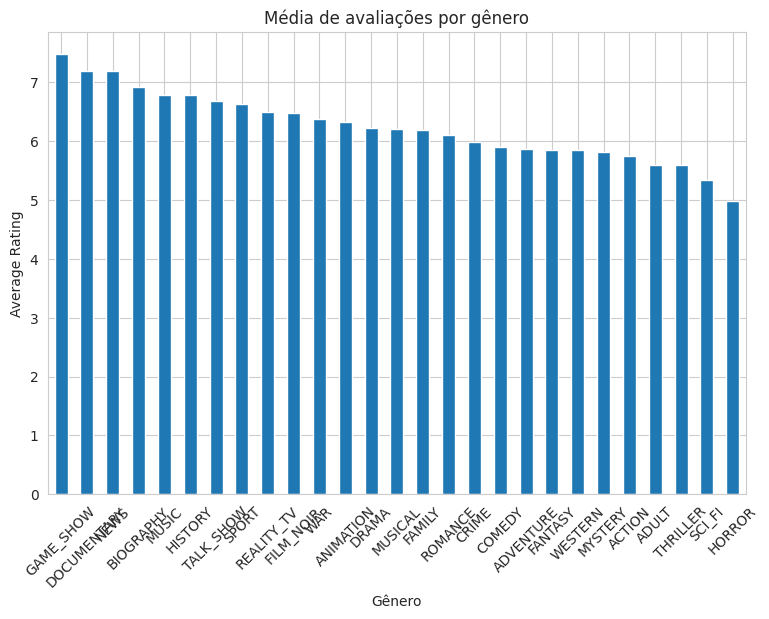

In [68]:
# Média de avaliação por gênero

genre_rating = (
    df_genres
    .groupby("genres")["averageRating"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,6))

genre_rating.plot(kind="bar")

plt.title("Média de avaliações por gênero")
plt.xlabel("Gênero")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

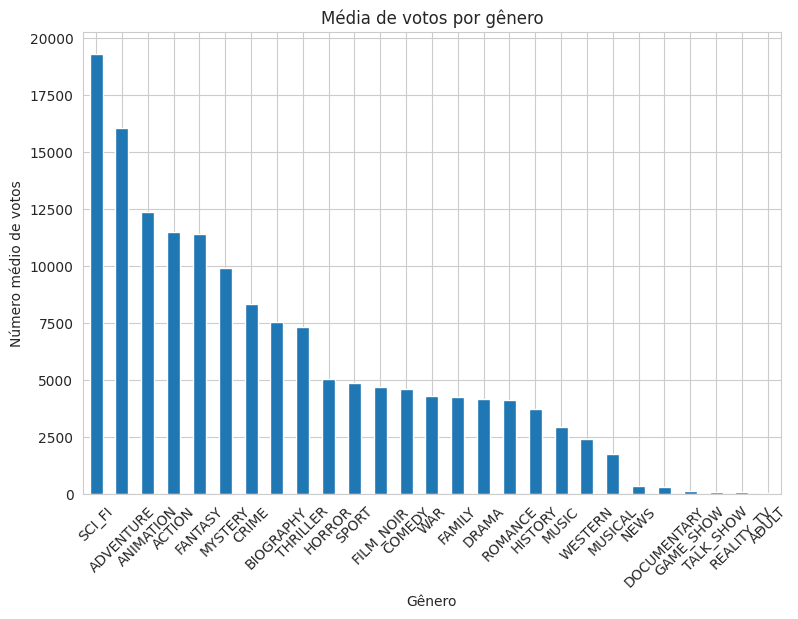

In [69]:
# Gêneros com mais engajamento

genre_votes = (
    df_genres
    .groupby("genres")["numVotes"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,6))

genre_votes.plot(kind="bar")

plt.title("Média de votos por gênero")
plt.xlabel("Gênero")
plt.ylabel("Número médio de votos")

plt.xticks(rotation=45)

plt.show()

In [42]:
# Score de desempenho

genre_performance = (
    df_genres
    .groupby("genres")
    .agg({
        "averageRating": "mean",
        "numVotes": "mean"
    })
)

# Normalização simples
genre_performance["rating_norm"] = (
    genre_performance["averageRating"] /
    genre_performance["averageRating"].max()
)

genre_performance["votes_norm"] = (
    genre_performance["numVotes"] /
    genre_performance["numVotes"].max()
)

# Score final
genre_performance["performance_score"] = (
    genre_performance["rating_norm"] * 0.6 +
    genre_performance["votes_norm"] * 0.4
)

genre_performance = genre_performance.sort_values(
    by="performance_score",
    ascending=False
)

genre_performance

,averageRating,numVotes,rating_norm,votes_norm,performance_score
genres,,,,,
SCI_FI,5.332186,19278.926467,0.714132,1.000000,0.828479
ADVENTURE,5.857933,16046.443438,0.784545,0.832331,0.803659
ANIMATION,6.313121,12367.884437,0.845507,0.641524,0.763914
BIOGRAPHY,6.919357,7557.487573,0.926700,0.392008,0.712823
FANTASY,5.842920,11400.541332,0.782534,0.591347,0.706059
ACTION,5.746036,11501.961620,0.769558,0.596608,0.700378
MYSTERY,5.805572,9941.522016,0.777532,0.515668,0.672786
CRIME,5.975920,8350.736297,0.800346,0.433154,0.653469
SPORT,6.633655,4861.700184,0.888436,0.252177,0.633932


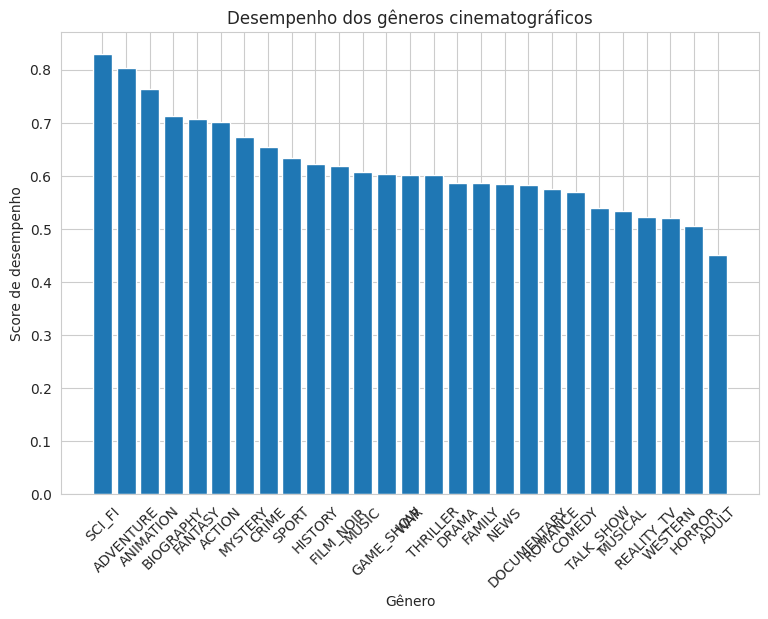

In [70]:
plt.figure(figsize=(9,6))

plt.bar(
    genre_performance.index,
    genre_performance["performance_score"]
)

plt.title("Desempenho dos gêneros cinematográficos")
plt.xlabel("Gênero")
plt.ylabel("Score de desempenho")

plt.xticks(rotation=45)

plt.show()

In [48]:
top_genres = genre_count.head(5).index

top_genres

Index(['DRAMA', 'COMEDY', 'DOCUMENTARY', 'ROMANCE', 'ACTION'], dtype='object', name='genres')

In [73]:
# BOOTSTRAP

bootstrap_results = {}

n_bootstrap = 1000

for genre in top_genres:

    ratings = df_genres[
        df_genres["genres"] == genre
    ]["averageRating"].dropna()

    means = []

    for _ in range(n_bootstrap):

        sample = ratings.sample(
            frac=1,
            replace=True
        )

        means.append(sample.mean())

    bootstrap_results[genre] = means

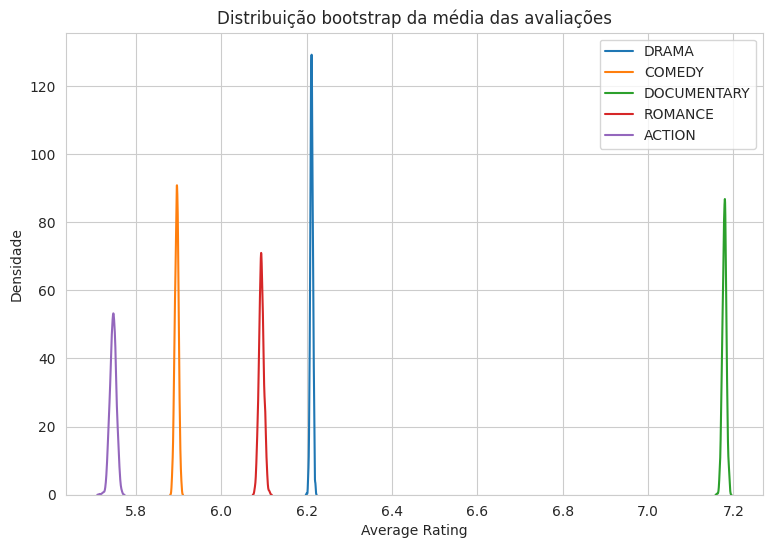

In [71]:
plt.figure(figsize=(9,6))

for genre, values in bootstrap_results.items():

    sns.kdeplot(values, label=genre)

plt.title("Distribuição bootstrap da média das avaliações")
plt.xlabel("Average Rating")
plt.ylabel("Densidade")

plt.legend()

plt.show()

In [51]:
# INTERVALO DE CONFIANÇA

confidence_intervals = []

for genre, values in bootstrap_results.items():

    lower = np.percentile(values, 2.5)
    upper = np.percentile(values, 97.5)

    confidence_intervals.append({
        "genre": genre,
        "lower": lower,
        "upper": upper,
        "mean": np.mean(values)
    })

ci_df = pd.DataFrame(confidence_intervals)

ci_df

,genre,lower,upper,mean
0,DRAMA,6.205884,6.217498,6.211612
1,COMEDY,5.886860,5.903715,5.895320
2,DOCUMENTARY,7.169856,7.188577,7.178981
3,ROMANCE,6.082762,6.105888,6.094058
4,ACTION,5.731871,5.760388,5.746367


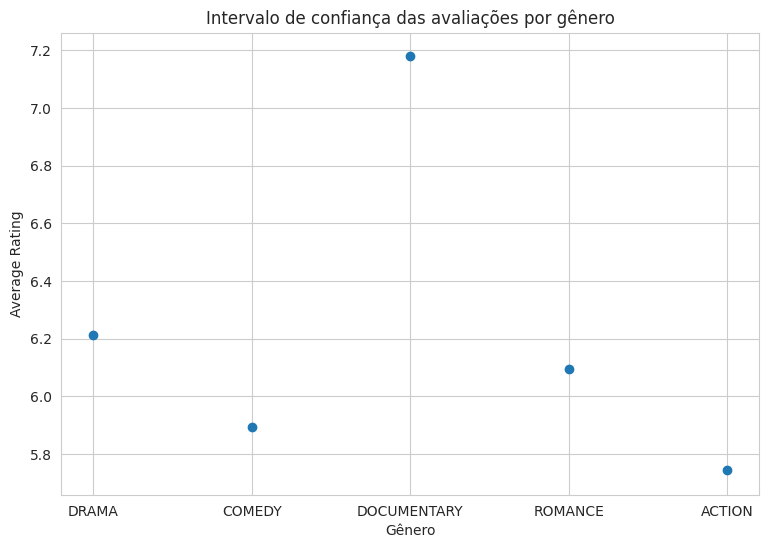

In [72]:
plt.figure(figsize=(9,6))

plt.errorbar(
    ci_df["genre"],
    ci_df["mean"],
    yerr=[
        ci_df["mean"] - ci_df["lower"],
        ci_df["upper"] - ci_df["mean"]
    ],
    fmt='o'
)

plt.title("Intervalo de confiança das avaliações por gênero")
plt.xlabel("Gênero")
plt.ylabel("Average Rating")

plt.show()

<Axes: ylabel='Density'>

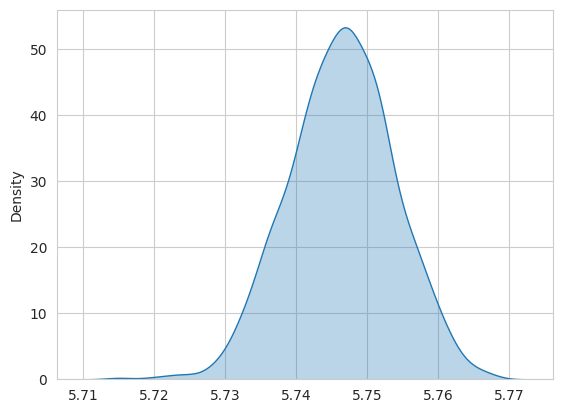

In [60]:
sns.kdeplot(
    values,
    label=genre,
    fill=True,
    alpha=0.3
)

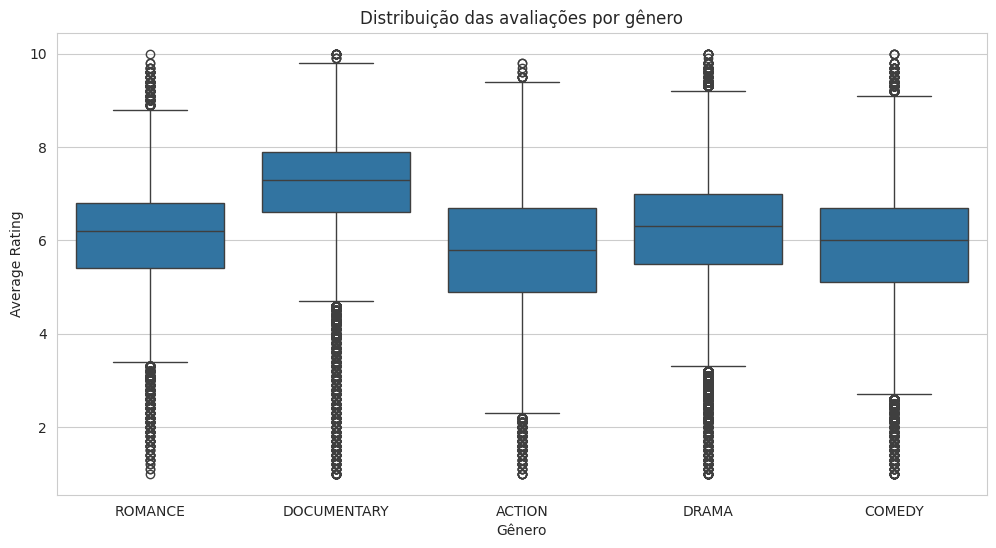

In [62]:
top_genres = genre_count.head(5).index

plot_df = df_genres[
    df_genres["genres"].isin(top_genres)
]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=plot_df,
    x="genres",
    y="averageRating"
)

plt.title("Distribuição das avaliações por gênero")
plt.xlabel("Gênero")
plt.ylabel("Average Rating")

plt.show()